In [1]:
!pip install transformers datasets scikit-learn matplotlib seaborn

In [2]:
import torch
import pandas as pd
import numpy as np

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset

In [3]:
news_df = pd.read_csv("../data/processed/final_news.csv")

print(news_df.shape)

news_df.head()

(44058, 7)


,title,text,subject,date,label,text_length,content
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0,10062,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1,2808,Kenya opposition leader calls for calm in slum...
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1,232,Egypt rejects U.S. decision to move its embass...
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0,610,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0,2658,Trump Rally Nearly Turns Into A Full-Blown Rac...


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    news_df["content"],
    news_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=news_df["label"]
)

In [5]:
tokenizer = BertTokenizer.from_pretrained("../models/fake_news_bert")

In [6]:
test_texts = X_test.tolist()
test_labels = y_test.tolist()

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

In [7]:
class NewsDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [8]:
test_dataset = NewsDataset(test_encodings, test_labels)

print("Testing Samples:", len(test_dataset))

Testing Samples: 8812


In [9]:
model = BertForSequenceClassification.from_pretrained(
    "../models/fake_news_bert"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [11]:
trainer = Trainer(
    model=model
)

In [12]:
results = trainer.evaluate(eval_dataset=test_dataset)

print(results)

Training Loss,Validation Loss,Step
No log,0.000039,0


{'eval_loss': 3.901010859408416e-05}


In [13]:
predictions = trainer.predict(test_dataset)

print(predictions)

PredictionOutput(predictions=array([[-7.1456304,  6.902277 ],
       [-7.123667 ,  6.865763 ],
       [ 7.0492663, -6.7425647],
       ...,
       [ 6.983887 , -6.7918067],
       [ 7.0145235, -6.7976665],
       [-7.019022 ,  6.757551 ]], shape=(8812, 2), dtype=float32), label_ids=array([1, 1, 0, ..., 0, 0, 1], shape=(8812,)), metrics={'test_loss': 3.901010859408416e-05, 'test_model_preparation_time': 0.004, 'test_runtime': 298.0174, 'test_samples_per_second': 29.569, 'test_steps_per_second': 3.698})


In [14]:
predicted_labels = np.argmax(predictions.predictions, axis=1)

print(predicted_labels[:10])

[1 1 0 0 0 1 0 0 1 1]


In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(test_labels, predicted_labels)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [16]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels,
    predicted_labels,
    average="binary"
)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        predicted_labels,
        target_names=["Fake", "Real"]
    )
)

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4570
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8812
   macro avg       1.00      1.00      1.00      8812
weighted avg       1.00      1.00      1.00      8812



In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predicted_labels)

print(cm)

[[4570    0]
 [   0 4242]]


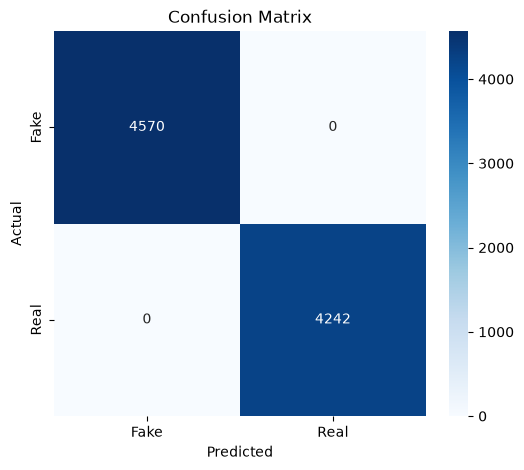

In [19]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [21]:
print(len(test_dataset))

8812
